**MAESTRÍA EN INTELIGENCIA ARTIFICIAL APLICADA**

**Curso: TC5053 - Ciencia y analítica de datos**

Tecnológico de Monterrey

Prof Grettel Barceló Alonso

**Semana 2**
Pandas para el análisis de datos en Python

---

*   NOMBRE: David Gerardo Pérez Sifuentes
*   MATRÍCULA: A01541553


---

En esta actividad trabajarás con el archivo `cleaned_weather.csv`, un extracto del conjunto de datos meteorológicos a lo largo de todo el año 2020 en una estación del Instituto *Max Planck* (Alemania) disponible en Kaggle.

Los datos meteorológicos fueron registrados cada 10 minutos e incluyen los siguientes indicadores:

*   `timestamp`: Fecha y hora de la observación.
*   `p`: Presión atmosférica en milibares (mbar)
*   `T`: Temperatura del aire en grados Celsius (°C)
*   `Tpot`: Temperatura potencial en Kelvin (K)
*   `rh`: Humedad relativa en porcentaje (%)
*   `VPact`: Presión real de vapor en milibares (mbar)
*   `sh`: Humedad específica en gramos por kilogramo (g/kg)
*   `H2OC`: Concentración de vapor de agua en milimoles por mol (mmol/mol) de aire seco
*   `rho`: Densidad del aire en gramos por metro cúbico (g/m³)
*   `wv`: Velocidad del viento en metros por segundo (m/s)
*   `wd`: Dirección del viento en grados (°)
*   `rain`: Precipitación total en milímetros (mm)
*   `raining`: Duración de la lluvia en segundos (s)

**NOTA IMPORTANTE:** Asegúrate de responder *explícitamente* todos los cuestionamientos.


In [1]:
# Importa las librerías necesarias

1.	Descarga el archivo: `cleaned_weather.csv` y guarda, en un dataframe (`weather_df`), todos sus registros.
- Determina la dimensionalidad del dataframe y obtén los identificadores de columnas.
- Renombra las columnas para facilitar la interpretación de los indicadores en los ejercicios siguientes:
  - `medicion, presion_atmosferica, temperatura_celsius, temperatura_kelvin, humedad_relativa, presion_vapor, humedad_especifica, concentracion_vapor, densidad_aire, velocidad_viento, direccion_viento, precipitacion_total, duracion_lluvia`
- Muestra los primeros y los últimos 5 registros.
- ¿Hay valores faltantes en el dataframe?





In [2]:
import pandas as pd
weather_df = pd.read_csv('cleaned_weather2.csv')
weather_df.head()

#muestr anombr eoriginal de las columnas
weather_df.loc[0].index

#dimensión del data frame
print(weather_df.shape)

#renombra las columnas del data frame
weather_df.columns=['medicion', 'presion_atmosferica', 'temperatura_celsius', 'temperatura_kelvin', 'humedad_relativa', 'presion_vapor', 'humedad_especifica', 'concentracion_vapor', 'densidad_aire', 'velocidad_viento', 'direccion_viento', 'precipitacion_total', 'duracion_lluvia']

#Muestra los primeros 5 datos de cada columna
print(weather_df.head())

#muestra los últimos 5 datos de cada columna
print(weather_df.tail())

#muestra cuantos datos del data frame son NO NULOS
print(weather_df.info())

(52696, 13)
        medicion  presion_atmosferica  temperatura_celsius  \
0  1/1/2020 0:10              1008.89                 0.71   
1  1/1/2020 0:20              1008.76                 0.75   
2  1/1/2020 0:30              1008.66                 0.73   
3  1/1/2020 0:40              1008.64                 0.37   
4  1/1/2020 0:50              1008.61                 0.33   

   temperatura_kelvin  humedad_relativa  presion_vapor  humedad_especifica  \
0              273.18              86.1           5.54                3.42   
1              273.22              85.2           5.49                3.39   
2              273.21              85.1           5.48                3.39   
3              272.86              86.3           5.41                3.35   
4              272.82              87.4           5.47                3.38   

   concentracion_vapor  densidad_aire  velocidad_viento  direccion_viento  \
0                 5.49        1280.62              1.02             2

Concluyo que no hay datos faltantes ya que no se eoncontraron datos no nulos

2. Determina el tipo de datos que tienen las columnas.
- Cambia la columna `medicion` a datetime utilizando el formato: `%d/%m/%y %H:%M`
- Obtén dos columnas adicionales separando `medicion` en `fecha` y `hora`

In [3]:
##Separa la columna de "medición" y crea un nuevo data frame (datetime) con una columna para hora y otra para fecha.
datetime_df = weather_df.medicion.str.split(' ', expand=True)

##renombra las columnas creadas por expand=True
datetime_df.columns = ['fecha', 'hora']

#Para quedarse con los 5 caracteres de la hora y qiotar los segundos
datetime_df['hora']=datetime_df.hora.str[:5]

##separa la columna de Fecha del datetime_df en nuevas columnas para día, mes y año.
date_df = datetime_df.fecha.str.split('-', expand=True)

#Agrega a weather_df las nuevas columnas creadas y elimina la vieja columna de medicion
weather_df = weather_df.join(datetime_df)

weather_df.columns=['medicion', 'presion_atmosferica', 'temperatura_celsius', 'temperatura_kelvin', 'humedad_relativa', 'presion_vapor', 'humedad_especifica', 'concentracion_vapor', 'densidad_aire', 'velocidad_viento', 'direccion_viento', 'precipitacion_total', 'duracion_lluvia','fecha','hora']

#Según la IA esto me da la columna de medición en otro formato que no sea texto porque con la manera del libro se crean muchas columnas nuevas
weather_df['fecha'] = pd.to_datetime(weather_df['fecha'], format='%m/%d/%Y').dt.strftime('%d/%m/%Y')

print(weather_df)

               medicion  presion_atmosferica  temperatura_celsius  \
0         1/1/2020 0:10              1008.89                 0.71   
1         1/1/2020 0:20              1008.76                 0.75   
2         1/1/2020 0:30              1008.66                 0.73   
3         1/1/2020 0:40              1008.64                 0.37   
4         1/1/2020 0:50              1008.61                 0.33   
...                 ...                  ...                  ...   
52691  12/31/2020 23:20               978.32                 2.28   
52692  12/31/2020 23:30               978.30                 2.13   
52693  12/31/2020 23:40               978.26                 1.99   
52694  12/31/2020 23:50               978.26                 2.07   
52695     1/1/2021 0:00               978.24                 2.01   

       temperatura_kelvin  humedad_relativa  presion_vapor  \
0                  273.18              86.1           5.54   
1                  273.22              85.2    

3. Determina la cantidad de valores únicos de cada columna.
- La columna `medicion` tiene un valor menos que el número total de filas del dataframe, lo que indica que hay una fecha duplicada. Identifica cuál es.
- Comprueba si las demás columnas también contienen los mismos valores; si es así, elimina  uno de los registros duplicados.


In [4]:
#.nunique Cuenta valores distintos hay en una columna
print(weather_df.nunique())

#.value_counts() cuanta las veces que aparece un mismo dato
print(weather_df.medicion.value_counts())

#Cuenta cuantas veces se encuentra un valor (buscando duplicados)
fr=weather_df.medicion.value_counts()

#filtra duplicados "on the fly"
dup=fr[fr>1].index[0]

#mascara boleana para filtrar duplicados
BM=weather_df.medicion==dup
weather_df[BM]

#Para ver si todos los datos son los mismos
print(weather_df[BM])

medicion               52695
presion_atmosferica     5052
temperatura_celsius     3680
temperatura_kelvin      3836
humedad_relativa        5494
presion_vapor           2059
humedad_especifica      1337
concentracion_vapor     2087
densidad_aire          14826
velocidad_viento         977
direccion_viento        8099
precipitacion_total       42
duracion_lluvia           61
fecha                    367
hora                     144
dtype: int64
medicion
5/12/2020 6:00      2
1/1/2020 0:10       1
1/1/2020 0:20       1
1/1/2020 0:30       1
1/1/2020 0:40       1
                   ..
12/31/2020 23:20    1
12/31/2020 23:30    1
12/31/2020 23:40    1
12/31/2020 23:50    1
1/1/2021 0:00       1
Name: count, Length: 52695, dtype: int64
             medicion  presion_atmosferica  temperatura_celsius  \
19043  5/12/2020 6:00               991.53                -1.57   
19044  5/12/2020 6:00               991.53                -1.57   

       temperatura_kelvin  humedad_relativa  presion_vapor

In [5]:
#elimina una de las filas duplicadas
weather_df.drop(index=19044, inplace=True)

nunique() para confirmar que todas las celdas de la columna de medición tengan valores. Una vez confirmado esto, con  value_counts() comprobamos cuales valores aparecen más de una vez.

fr es la variable para guardar el resultado de value_counts() y poder filtrar los duplicados con una función booleana.

Una vez que se comprueba que todos los datos en ambas filas son los mismos, se elimina la fila 19044 con .drop(index).


4. Imprime nuevamente las cantidad de valores únicos por columna.
- ¿Por qué son 144 horas diferentes?
- La cantidad de combinaciones únicas de fecha y hora no coincide con el número total de mediciones. Aunque no haya valores NaN, esto no garantiza que no se hayan omitido registros. Identifica las fechas en las que faltan mediciones.
- Una vez concluido el análisis de mediciones faltantes, elimina todos los registros que no correspondan al año 2020 y la columna `medicion`.


In [6]:
print(weather_df.nunique())

#variable para guardar los resultados de goupby. agrupa cosas, en este caso la fecha.
#Usé IA para poder encontrar que se puede agrupar por cantidad con .size
dd=weather_df.groupby('fecha').size()

#Para encontrar fechas extrañas con función booleana
fe1=dd[dd<144]
fe2=dd[dd>144]

print(fe1, fe2)

print(weather_df.tail())

medicion               52695
presion_atmosferica     5052
temperatura_celsius     3680
temperatura_kelvin      3836
humedad_relativa        5494
presion_vapor           2059
humedad_especifica      1337
concentracion_vapor     2087
densidad_aire          14826
velocidad_viento         977
direccion_viento        8099
precipitacion_total       42
duracion_lluvia           61
fecha                    367
hora                     144
dtype: int64
fecha
01/01/2020    143
01/01/2021      1
29/05/2020    135
dtype: int64 Series([], dtype: int64)
               medicion  presion_atmosferica  temperatura_celsius  \
52691  12/31/2020 23:20               978.32                 2.28   
52692  12/31/2020 23:30               978.30                 2.13   
52693  12/31/2020 23:40               978.26                 1.99   
52694  12/31/2020 23:50               978.26                 2.07   
52695     1/1/2021 0:00               978.24                 2.01   

       temperatura_kelvin  humedad_rela

In [7]:
weather_df.drop(index=52695, inplace=True)

print(weather_df)

               medicion  presion_atmosferica  temperatura_celsius  \
0         1/1/2020 0:10              1008.89                 0.71   
1         1/1/2020 0:20              1008.76                 0.75   
2         1/1/2020 0:30              1008.66                 0.73   
3         1/1/2020 0:40              1008.64                 0.37   
4         1/1/2020 0:50              1008.61                 0.33   
...                 ...                  ...                  ...   
52690  12/31/2020 23:10               978.36                 2.27   
52691  12/31/2020 23:20               978.32                 2.28   
52692  12/31/2020 23:30               978.30                 2.13   
52693  12/31/2020 23:40               978.26                 1.99   
52694  12/31/2020 23:50               978.26                 2.07   

       temperatura_kelvin  humedad_relativa  presion_vapor  \
0                  273.18             86.10           5.54   
1                  273.22             85.20    

Los registros de hora son 144 porque se toman cada 10minutos, al haber 24 hrs al día, esto da 144 registros.

5. Obtén un dataframe `indicadores_diarios` que sólo almacene el mayor valor de las mediciones por fecha para responder:
- ¿Cuál fue la máxima precipitación y a qué fecha pertenece?
- ¿Cuáles fueron los tres días con las velocidades de viento más altas registradas?
- ¿Cuántos días rebasaron el 90% de humedad relativa y los 30° celsius?

In [8]:
indicadores_diarios_df=weather_df.groupby('fecha').max()
print(indicadores_diarios_df)

                   medicion  presion_atmosferica  temperatura_celsius  \
fecha                                                                   
01/01/2020    1/1/2020 9:50              1008.89                 4.58   
01/02/2020    2/1/2020 9:50               983.52                13.11   
01/03/2020    3/1/2020 9:50               973.09                10.88   
01/04/2020    4/1/2020 9:50              1000.05                 8.91   
01/05/2020    5/1/2020 9:50               977.99                14.20   
...                     ...                  ...                  ...   
31/05/2020   5/31/2020 9:50               996.24                19.34   
31/07/2020   7/31/2020 9:50               993.56                28.60   
31/08/2020   8/31/2020 9:50               991.66                18.38   
31/10/2020  10/31/2020 9:50               997.60                15.08   
31/12/2020  12/31/2020 9:50               980.46                 3.43   

            temperatura_kelvin  humedad_relativa  

In [9]:
mp = indicadores_diarios_df['precipitacion_total'].max()
BM = indicadores_diarios_df['precipitacion_total'] == mp
print(indicadores_diarios_df[BM])

#probando si se puede combinar .sort_values que ordena los valores de la columna que elijas y tail(3) para mostrar lo súltimos 3
print(indicadores_diarios_df.sort_values('velocidad_viento').tail(3))

#máscaras boleanas para filtrar la humedad y la temperatura
h=indicadores_diarios_df['humedad_relativa']>90
t=indicadores_diarios_df['temperatura_celsius']>30

#creando variable para ver cuantas fechas cumplen contos 2 parámetros
dc_df=indicadores_diarios_df[h&t]

print(dc_df.index)


                  medicion  presion_atmosferica  temperatura_celsius  \
fecha                                                                  
16/06/2020  6/16/2020 9:50               990.12                23.86   

            temperatura_kelvin  humedad_relativa  presion_vapor  \
fecha                                                             
16/06/2020              298.08              97.9          18.56   

            humedad_especifica  concentracion_vapor  densidad_aire  \
fecha                                                                
16/06/2020               11.78                18.81        1188.93   

            velocidad_viento  direccion_viento  precipitacion_total  \
fecha                                                                 
16/06/2020              4.39             353.8                 11.2   

            duracion_lluvia  hora  
fecha                              
16/06/2020              600  9:50  
                  medicion  presion_atmosferica 

La mayor precipitación fue de 11.2mm y ocurrió el 16 de Junio del 2020.

Los 3 día con las velocidades del viento más altas fueron 9 de febrero con 12.52 m/s. El segundo día fue el 16 de febrero con 13m/s y el día con la máxima velocidad fue el 10 de febrero con 13.77 m/s

En 5 días se tuvieron más de 90% de humedad y más de 30°C. Siendo estos 11/08/2020', '12/08/2020', '15/09/2020', '20/08/2020', '21/08/2020.

6. La función `describe()` resume múltiples estadísticas descriptivas. Utiliza esta función para explorar y responder las preguntas sobre las variables en el dataframe de `indicadores_diarios `:
- ¿Cuál es la desviación estándar de la concentración de vapor y qué indica?
- ¿Cuál es la mediana de la presión atmosférica y qué significa?
- ¿Cuál es el tercer cuartil de la duración de la lluvia y cómo se interpreta?

In [10]:
print(indicadores_diarios_df.describe())

       presion_atmosferica  temperatura_celsius  temperatura_kelvin  \
count           366.000000           366.000000          366.000000   
mean            992.977842            15.343770          289.431667   
std               8.543447             7.850339            7.942175   
min             959.900000            -0.120000          273.460000   
25%             988.015000             8.840000          282.732500   
50%             993.300000            15.060000          289.160000   
75%             998.432500            21.695000          295.957500   
max            1020.070000            34.800000          309.130000   

       humedad_relativa  presion_vapor  humedad_especifica  \
count        366.000000     366.000000          366.000000   
mean          90.886530      11.409454            7.214016   
std            9.201588       4.507555            2.872647   
min           55.440000       3.320000            2.050000   
25%           85.400000       7.647500            

La desviación estandar de la concentración de vapor es de 4.57, mientras que el promedio de los datos es de 11.54, por lo cual se concluye que los valores de concentración de vapor que contiene este data frame muestran demasiada dispesión.

La mediana de la presión atmosférica es de 992.98. Al ver una desviación estandar de 8.55, significa que los datos no presentan mucha dispersión y muestra una tendencia a rondar un rango de valores parecidos.

El tercer cuartil de la duración de la lluvia indica que en el 75% de los dias registrados hubo 600 segundos de lluvia o menos.

7.	Dibuja un histograma para cada una de las columnas de `indicadores_diarios`.

<Axes: ylabel='Frequency'>

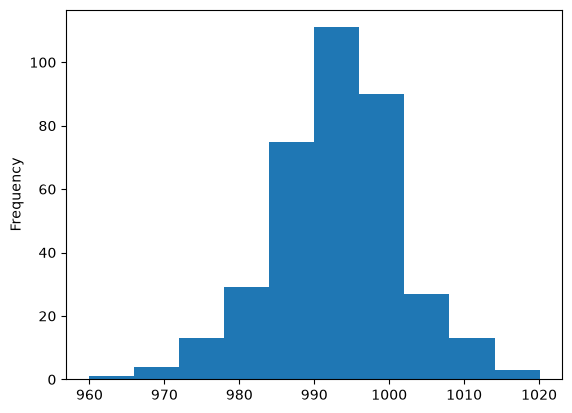

In [11]:
indicadores_diarios_df['presion_atmosferica'].plot.hist()

<Axes: ylabel='Frequency'>

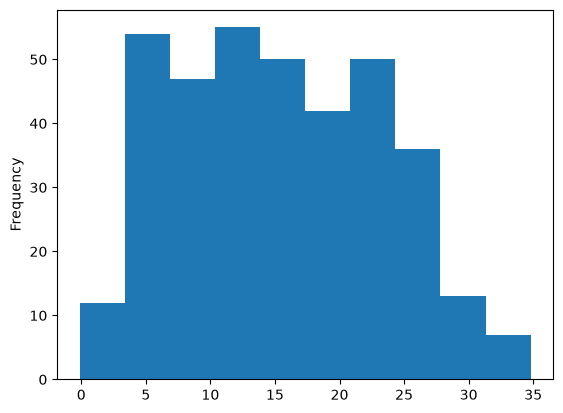

In [12]:
indicadores_diarios_df['temperatura_celsius'].plot.hist()

<Axes: ylabel='Frequency'>

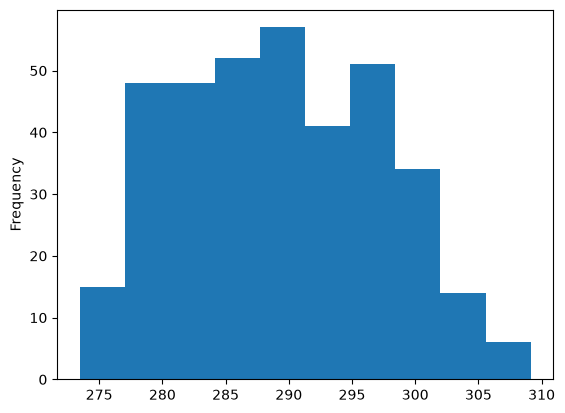

In [13]:
indicadores_diarios_df['temperatura_kelvin'].plot.hist()

<Axes: ylabel='Frequency'>

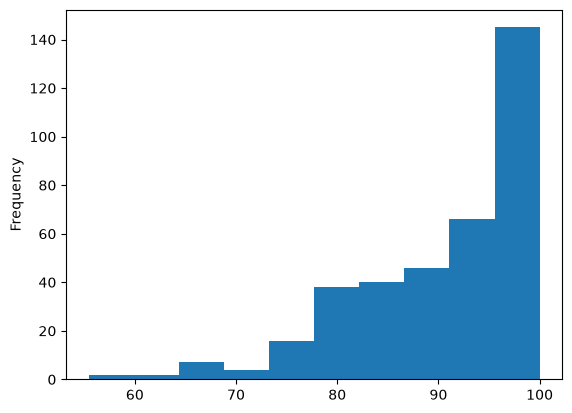

In [14]:
indicadores_diarios_df['humedad_relativa'].plot.hist()

<Axes: ylabel='Frequency'>

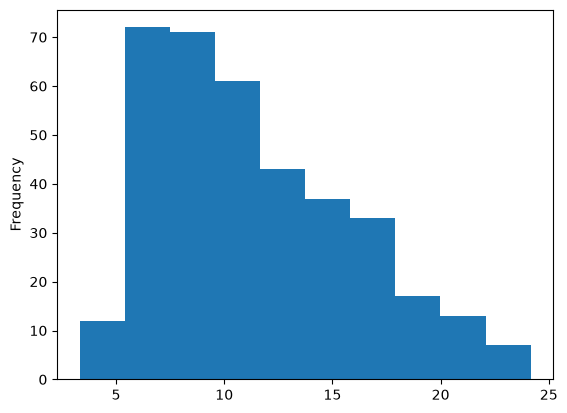

In [15]:
indicadores_diarios_df['presion_vapor'].plot.hist()

<Axes: ylabel='Frequency'>

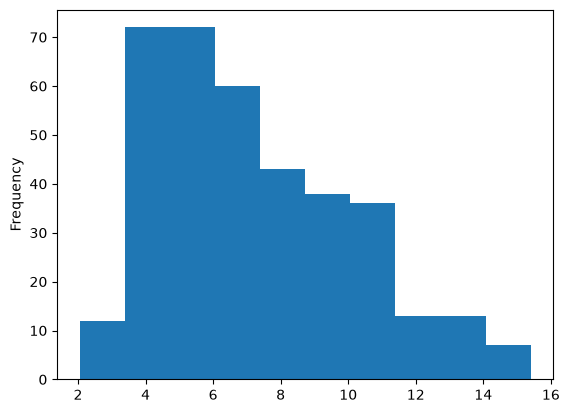

In [16]:
indicadores_diarios_df['humedad_especifica'].plot.hist()

<Axes: ylabel='Frequency'>

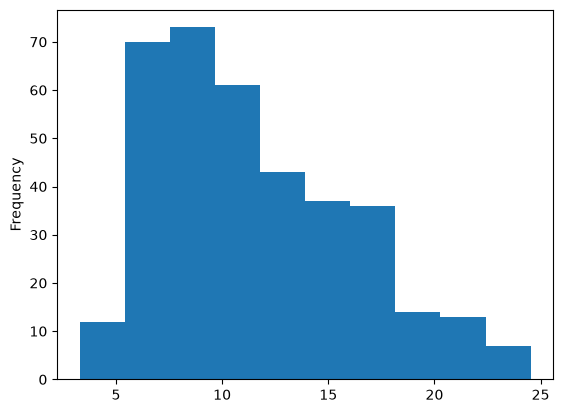

In [17]:
indicadores_diarios_df['concentracion_vapor'].plot.hist()

<Axes: ylabel='Frequency'>

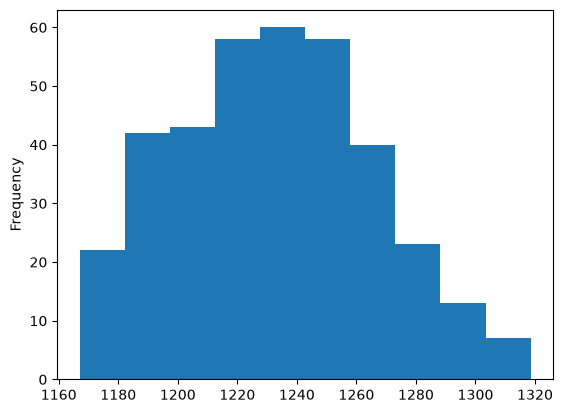

In [18]:
indicadores_diarios_df['densidad_aire'].plot.hist()

<Axes: ylabel='Frequency'>

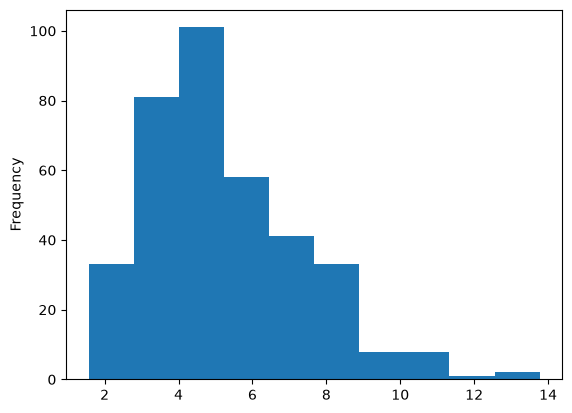

In [19]:
indicadores_diarios_df['velocidad_viento'].plot.hist()

<Axes: ylabel='Frequency'>

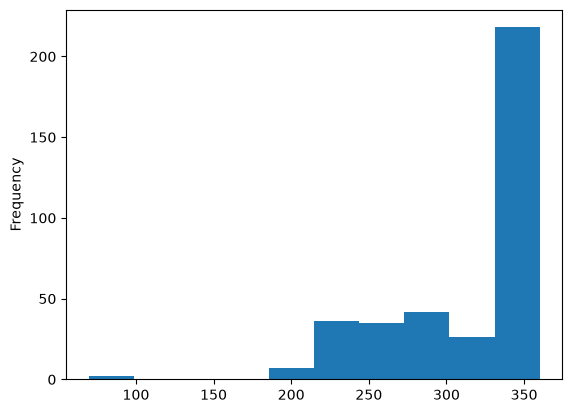

In [20]:
indicadores_diarios_df['direccion_viento'].plot.hist()

<Axes: ylabel='Frequency'>

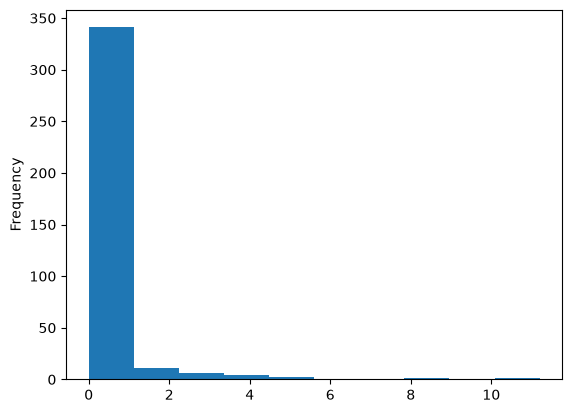

In [21]:
indicadores_diarios_df['precipitacion_total'].plot.hist()

<Axes: ylabel='Frequency'>

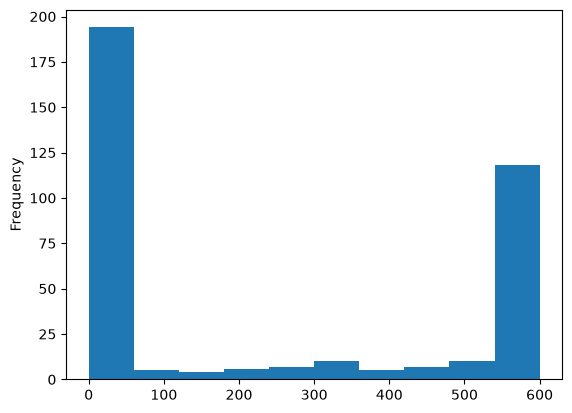

In [22]:
indicadores_diarios_df['duracion_lluvia'].plot.hist()

8. Utiliza el dataframe de indicadores diarios para crear un nuevo dataframe `indicadores_mensuales`. Para ello:
- Crea una nueva columna `mes` a partir de la fecha que se encuentra en el índice.
- Haciendo uso de `groupby()`, calcula los promedios mensuales y conserva únicamente las columnas `humedad_relativa`, `temperatura_celsius` y `velocidad_viento` en el nuevo dataframe.

In [23]:
#convertir el índice a formato fecha porque ya no entendí por que no jala la del paso de arriba
#función pd.to_datetime() sacada fue recomendación de la IA para ya no revolverme con todo lo qu ehice arriba. Convierte texto en números directamente
indicadores_diarios_df.index=pd.to_datetime(indicadores_diarios_df.index, dayfirst=True)

#crear la columna 'mes' a partir del índice
indicadores_diarios_df['mes']=indicadores_diarios_df.index.month

#agrupar por mes y calcular los promedios mensuales
indicadores_mensuales_df = indicadores_diarios_df.groupby('mes').mean(numeric_only=True)

#conservar solo las columnas pedidas
indicadores_mensuales_df = indicadores_mensuales_df[['humedad_relativa', 'temperatura_celsius', 'velocidad_viento']]

print(indicadores_mensuales_df)

     humedad_relativa  temperatura_celsius  velocidad_viento
mes                                                         
1           89.776129             6.821290          5.031935
2           85.719655             8.962414          7.489655
3           85.372903             9.683871          6.421290
4           80.938667            16.879667          4.997000
5           87.464839            17.135484          4.865806
6           94.256000            22.212000          5.296667
7           85.959355            24.336129          4.830323
8           92.002581            26.097742          5.040323
9           97.570000            21.571667          4.153333
10          96.950645            14.089355          5.675484
11          96.983333            10.561667          4.399000
12          97.510968             5.680000          4.817097


9. Construye el mismo dataframe mensual, pero esta vez utilizando la función `pivot_table()`.
- Añade la columna `indice_calor` usando la fórmula de Thom (*Temperature - Humidity Index*, TDI):
> `temperatura_celsius + 0.33 x humedad_relativa - 0.7 x velocidad_viento - 4`

In [24]:
#convertir  indicadores mensuales en pivot table
indicadores_mensuales_df=indicadores_diarios_df.pivot_table(index='mes', values=['humedad_relativa','temperatura_celsius','velocidad_viento'])

print(indicadores_mensuales_df)

#LaIA indicó que con indicadores_mensuales_df['indice_calor'] puedo crear la nueva columna sin tanto rollo. Lo demás ya la va llenado 
indicadores_mensuales_df['indice_calor']=(indicadores_mensuales_df['temperatura_celsius']+0.33*indicadores_mensuales_df['humedad_relativa']-0.7*indicadores_mensuales_df['velocidad_viento']-4)
print(indicadores_mensuales_df)

     humedad_relativa  temperatura_celsius  velocidad_viento
mes                                                         
1           89.776129             6.821290          5.031935
2           85.719655             8.962414          7.489655
3           85.372903             9.683871          6.421290
4           80.938667            16.879667          4.997000
5           87.464839            17.135484          4.865806
6           94.256000            22.212000          5.296667
7           85.959355            24.336129          4.830323
8           92.002581            26.097742          5.040323
9           97.570000            21.571667          4.153333
10          96.950645            14.089355          5.675484
11          96.983333            10.561667          4.399000
12          97.510968             5.680000          4.817097
     humedad_relativa  temperatura_celsius  velocidad_viento  indice_calor
mes                                                                    

10. Recuerda que de las cuatro funciones estudiadas para manipular la estructura del dataframe:
- `melt/pivot` hacen las transformaciones de manera controlada, es decir puedes
definir por medio de sus parámetros qué variables quedarán como índices, columnas y valores.
- `stack/unstack` la conversión se aplica siempre sobre los niveles inferiores de index/columns.
- Convierte el dataframe del ejercicio anterior a formato largo usando: `melt()` y `stack()` y comenta las diferencias.

In [25]:
stack_df=indicadores_mensuales_df.stack()

print(stack_df)

#De acuerdo on la IA, se requiere el reset_index porque por fuerza se ocupa mes como coulna para que esto funcione
indicadores_mensuales_df=indicadores_mensuales_df.reset_index()

long_df=indicadores_mensuales_df.melt(id_vars='mes', var_name='indicador', value_name='valor')

print(long_df)

mes                     
1    humedad_relativa       89.776129
     temperatura_celsius     6.821290
     velocidad_viento        5.031935
     indice_calor           28.925058
2    humedad_relativa       85.719655
     temperatura_celsius     8.962414
     velocidad_viento        7.489655
     indice_calor           28.007141
3    humedad_relativa       85.372903
     temperatura_celsius     9.683871
     velocidad_viento        6.421290
     indice_calor           29.362026
4    humedad_relativa       80.938667
     temperatura_celsius    16.879667
     velocidad_viento        4.997000
     indice_calor           36.091527
5    humedad_relativa       87.464839
     temperatura_celsius    17.135484
     velocidad_viento        4.865806
     indice_calor           38.592816
6    humedad_relativa       94.256000
     temperatura_celsius    22.212000
     velocidad_viento        5.296667
     indice_calor           45.608813
7    humedad_relativa       85.959355
     temperatura_celsius 

La diferencia entre stack y melt es que stack a mi parecer te da la tabla más ordenada, lo que ami punto de vista es más facil de leer. Además de que es más facil de programar porque después de haber estado Batallando con melt, le pregunté a la IA y dijo que para melt se ocupa resetear el index. 

Para mi resultó más conveniente Stack.

---

**Declaración de uso de IA**

Si aplica, deberá indicarse la herramienta y el modelo empleado en la entrega, así como la finalidad de su uso (generación de código / depuración / optimización).

Por ejemplo:

*   OpenAI. (2026). *ChatGPT (basado en GPT-4)* [Modelo de lenguaje grande], utilizado para generación de código y depuración. https://chat.openai.com/

---
Declaración de uso de IA para esta tarea:

*   Anthropic. (2026). Claude (Sonnet 4.5) [Modelo de lenguaje grande], utilizado para consultar por qué no funciona sierta línea si se esta haciendo igual que en el material de apoyo y para complementar con una que otra función que no venía en el material de apoyo para simplificar algunos pasos. https://claude.ai/